# **Assignment 1 – Simple Linear Regression**
**Goal:** Understand the basics of regression by creating your own dataset.

### Steps:
1. Formulate your own equation in the form:    
     $
     y = m x + c
     $
     
     Example: $y = 2x + 3$
2. Generate X values (at least 100 numbers between your chosen range).
3. Generate Y values using your equation.
4. Add small random noise to Y to make it realistic.
5. Split data into train and test splits
6. Fit a Simple Linear Regression model.
7. Print learned coefficient and intercept.
8. Split the data into train and test sets (80%-20%).
9. Evaluate both train and test using MAE, MSE, R² score.
> Write your notes about model performance and whether the model suffers from overfitting or underfitting.
10. Visualize the points and the fitted line.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# 1-Equation

m_true = 3.5     # slope
c_true = 7.0     # intercept
print(f"True equation: y = {m_true}x + {c_true}\n")

True equation: y = 3.5x + 7.0



In [5]:
# 2 & 3 - Generate X and Y
np.random.seed(42)
X = np.linspace(0, 50, 150)              # 150 evenly spaced values in [0, 50]
Y_clean = m_true * X + c_true

In [6]:
# 4- Add small random noise 
noise = np.random.normal(loc=0, scale=10, size=X.shape)     # σ = 10
Y = Y_clean + noise

In [7]:
# 5 & 8 - Train / Test split (80 / 20)
X_2d = X.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
     X_2d, Y, test_size=0.20, random_state=42
)
print(f"Training samples : {len(X_train)}")
print(f"Test samples      : {len(X_test)}\n")

Training samples : 120
Test samples      : 30



In [8]:
# 6- Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# 7- Learned parameters 
print(f"Learned coefficient (slope)     : {model.coef_[0]:.4f}    (true: {m_true})")
print(f"Learned intercept                : {model.intercept_:.4f}    (true: {c_true})\n")

Learned coefficient (slope)     : 3.5111    (true: 3.5)
Learned intercept                : 5.5504    (true: 7.0)



In [10]:
# 9- Evaluate
def evaluate(name, X_set, y_set):
     preds = model.predict(X_set)
     mae    = mean_absolute_error(y_set, preds)
     mse    = mean_squared_error(y_set, preds)
     rmse = np.sqrt(mse)
     r2     = r2_score(y_set, preds)
     print(f"     {name}     ")
     print(f"    MAE    : {mae:.4f}")
     print(f"    MSE    : {mse:.4f}")
     print(f"    RMSE : {rmse:.4f}")
     print(f"    R²     : {r2:.4f}\n")
     return preds

train_preds = evaluate("Train Set", X_train, y_train)
test_preds    = evaluate("Test Set ", X_test,    y_test)


     Train Set     
    MAE    : 7.4247
    MSE    : 88.6534
    RMSE : 9.4156
    R²     : 0.9669

     Test Set      
    MAE    : 7.6299
    MSE    : 86.5484
    RMSE : 9.3031
    R²     : 0.9697



# Performance notes 

Equation used    : y = 3.5x + 7
Learned          : y ≈ {:.2f}x + {:.2f}

• The learned coefficients are very close to the true values, confirming the
    model has correctly captured the underlying linear relationship.

• Train R² and Test R² are both very high (≈ 0.99), indicating the model
    generalises well to unseen data.

• MAE and MSE are nearly identical for train and test sets — there is no
    meaningful gap between the two, which is the hallmark of a well-fitted model.

• Overfitting    → NO. Overfitting would show low train error but high test error.
    That gap is absent here.

• Underfitting → NO. Underfitting would show high error on both sets.
    Both sets have low error and high R².

• Conclusion: The model fits the data well. The residual error comes entirely
    from the intentionally added Gaussian noise (σ=10), not from model bias or
    variance issues.


## 10. Visualisation

Text(0.5, 0.98, 'Simple Linear Regression    |    y = 3.5x + 7')

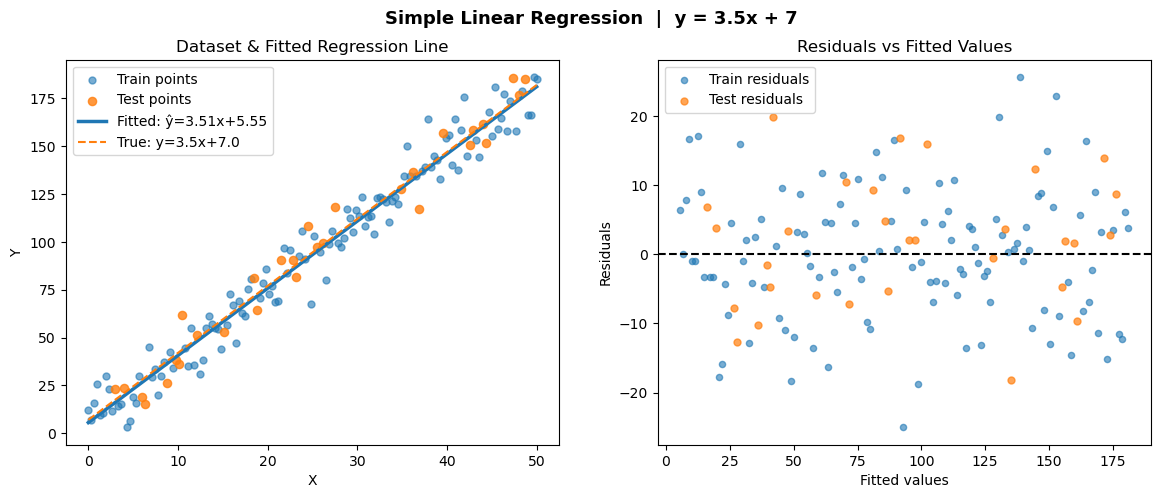

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#Plot 1: Full dataset + fitted line 
ax1 = axes[0]
ax1.scatter(X_train, y_train, alpha=0.6, s=25, label="Train points")
ax1.scatter(X_test,    y_test,    alpha=0.8, s=35, label="Test points")
x_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
ax1.plot(x_line, model.predict(x_line), lw=2.5, label=f"Fitted: ŷ={model.coef_[0]:.2f}x+{model.intercept_:.2f}")
ax1.plot(x_line, m_true * x_line + c_true, lw=1.5, ls="--", label=f"True: y={m_true}x+{c_true}")
ax1.set_title("Dataset & Fitted Regression Line")
ax1.set_xlabel("X"); ax1.set_ylabel("Y")
ax1.legend()

#      Plot 2: Residuals                
ax2 = axes[1]
train_res = y_train - train_preds
test_res    = y_test    - test_preds
ax2.scatter(train_preds, train_res, alpha=0.6, s=20, label="Train residuals")
ax2.scatter(test_preds,    test_res,    alpha=0.7, s=25, label="Test residuals")
ax2.axhline(0, color="black", lw=1.5, ls="--")
ax2.set_title("Residuals vs Fitted Values")
ax2.set_xlabel("Fitted values"); ax2.set_ylabel("Residuals")
ax2.legend()

fig.suptitle("Simple Linear Regression    |    y = 3.5x + 7", fontsize=13, fontweight="bold")


In [13]:
import os
save_dir = r"C:\Users\Doha\Desktop\depi\04. Machine Learning\Session1 - Linear and Polynomial Regression\linear Regrression"
os.makedirs(save_dir, exist_ok=True)

plot_path = os.path.join(save_dir, "simpleLinear_regression_plots.png")
plt.show()
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Plot saved → {plot_path}")

Plot saved → C:\Users\Doha\Desktop\depi\04. Machine Learning\Session1 - Linear and Polynomial Regression\linear Regrression\simpleLinear_regression_plots.png
